In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [4]:
df = df.copy()

df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

In [5]:
target = "median_house_value"
X = df.drop(columns=[target])
y = df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [7]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = ["ocean_proximity"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lin_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mae_lr, rmse_lr, r2_lr

(49645.49244453642, np.float64(69127.03829924985), 0.635339233523819)

In [9]:
rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf

(31766.87261264535, np.float64(49499.51559558054), 0.8130200506191368)

In [10]:
pd.DataFrame({
    "Modell": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})

,Modell,MAE,RMSE,R2
0,Linear Regression,49645.492445,69127.038299,0.635339
1,Random Forest,31766.872613,49499.515596,0.813020


In [11]:
unsupervised_features = [
    "longitude",
    "latitude",
    "median_income",
    "housing_median_age",
    "rooms_per_household",
    "population_per_household"
]

X_unsup = df[unsupervised_features]

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.32337271, 0.23609306])

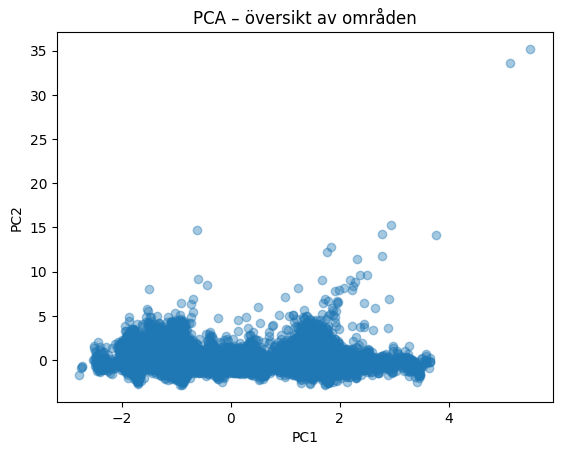

In [14]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA – översikt av områden")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.groupby("cluster")[unsupervised_features].mean()

,longitude,latitude,median_income,housing_median_age,rooms_per_household,population_per_household
cluster,,,,,,
0,-118.020261,33.968446,3.206912,30.538510,4.744520,3.082124
1,-121.753756,37.988009,3.594596,29.302808,5.401038,2.814459
2,-118.498169,34.448574,6.811462,20.558793,7.743364,2.951576
3,-121.063333,38.016667,6.669400,42.333333,5.795482,781.836386


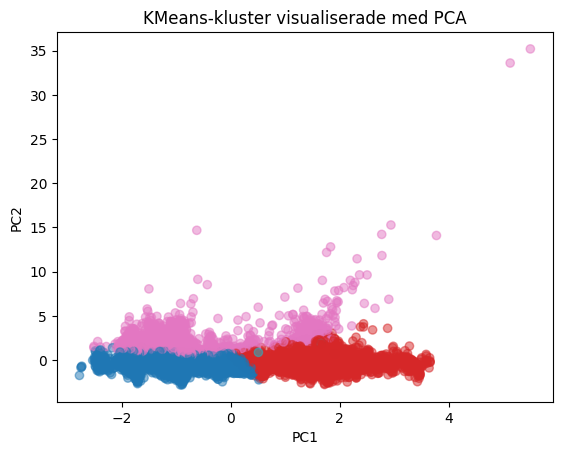

In [16]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], cmap="tab10", alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans-kluster visualiserade med PCA")
plt.show()